<a href="https://colab.research.google.com/github/aaryaddeshmukh10/Aml-experiments-Aarya-Deshmukh/blob/main/AML_Exp_1exp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import Libararies**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

**Load Dataset**

In [ ]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

print("First 5 Rows:")
print(df.head())

First 5 Rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

**Dataset Information**

In [ ]:
print("Shape:", df.shape)

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (891, 12)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Statistical Summary:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   

**Handle Missing Values**

In [ ]:
# Fill missing Age values with mean
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Fill missing Embarked values with mode
df['Embarked'] = df['Embarked'].fillna(
    df['Embarked'].mode()[0]
)

# Drop Cabin column
df.drop('Cabin', axis=1, inplace=True)

print("Missing Values After Cleaning:\n")

print(df.isnull().sum())

Missing Values After Cleaning:

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


**Detect and Remove Outliers**

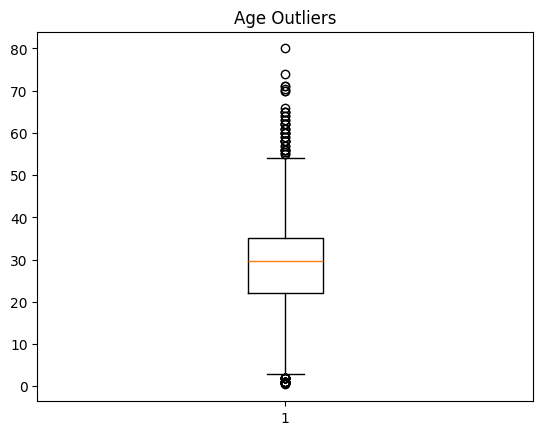

Outliers Removed


In [ ]:
# Boxplot
plt.boxplot(df['Age'])

plt.title("Age Outliers")

plt.show()

# IQR Method
Q1 = df['Age'].quantile(0.25)

Q3 = df['Age'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

df = df[
    (df['Age'] >= lower) &
    (df['Age'] <= upper)
]

print("Outliers Removed")

**Encode Categorical Data**

In [ ]:
# Convert Sex column into numeric
df['Sex'] = df['Sex'].map({
    'male': 0,
    'female': 1
})

# One-hot encoding for Embarked
df = pd.get_dummies(
    df,
    columns=['Embarked'],
    drop_first=True
)

print("Encoded Dataset:")

print(df.head())

Encoded Dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    0  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    1  38.0      1      0   
2                             Heikkinen, Miss. Laina    1  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    1  35.0      1      0   
4                           Allen, Mr. William Henry    0  35.0      0      0   

             Ticket     Fare  Embarked_Q  Embarked_S  
0         A/5 21171   7.2500       False        True  
1          PC 17599  71.2833       False       False  
2  STON/O2. 3101282   7.9250       False        True  
3            113803  53.1000       False        True  
4   

**Feature Scaling**

In [ ]:
print("Before Scaling:\n")

print(df[['Age', 'Fare']].head())

# Scaling
scaler = StandardScaler()

df[['Age', 'Fare']] = scaler.fit_transform(
    df[['Age', 'Fare']]
)

print("\nAfter Scaling:\n")

print(df[['Age', 'Fare']].head())

Before Scaling:

    Age     Fare
0  22.0   7.2500
1  38.0  71.2833
2  26.0   7.9250
3  35.0  53.1000
4  35.0   8.0500

After Scaling:

        Age      Fare
0 -0.676034 -0.485389
1  0.896210  0.797171
2 -0.282973 -0.471869
3  0.601414  0.432967
4  0.601414 -0.469366
